# Scene Analysis Explorer
Visualises the embedding landscape, per-frame quality metrics, and optical flow stats produced by `scene_selection.py`.

**Set the two paths below, then Run All.**

In [75]:
# DJI_20250514105245_0135_D
# DJI_20250801134716_0192_D
# DJI_20250802144037_0199_D
# DJI_20250802150946_0204_D
# DJI_20250803144140_0220_D

video_prefix = "DJI_20250802144037_0199_D"

JSON_PATH = "../local/videos_test/" + video_prefix + ".analysis.json"
NPZ_PATH  = "../local/videos_test/" + video_prefix + ".embeddings.npz"

In [76]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from scipy.spatial.distance import cosine as cosine_dist
from scipy.signal import find_peaks

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

# ── Load data ──────────────────────────────────────────────────────────────
with open(JSON_PATH) as f:
    data = json.load(f)

npz        = np.load(NPZ_PATH)
embeddings = npz["embeddings"]   # (N, D)
emb_ts     = npz["timestamps"]   # (N,)

scenes     = data["scenes"]
boundaries = data["boundaries"]
duration   = data["duration"]

fm  = pd.DataFrame(data["frame_metrics"]).sort_values("timestamp").reset_index(drop=True)
flo = pd.DataFrame(data["flow_stats"]).sort_values("timestamp").reset_index(drop=True)

# Sort scenes by start_time for consistent colouring
scenes_sorted = sorted(scenes, key=lambda s: s["start_time"])
SCENE_COLORS  = plt.cm.Set2(np.linspace(0, 0.8, len(scenes_sorted)))

def scene_color(ts):
    for i, s in enumerate(scenes_sorted):
        if s["start_time"] <= ts < s["end_time"]:
            return SCENE_COLORS[i]
    return "grey"

def add_scene_bands(ax, alpha=0.08):
    """Shade axes background by scene."""
    for i, s in enumerate(scenes_sorted):
        ax.axvspan(s["start_time"], s["end_time"], color=SCENE_COLORS[i], alpha=alpha)
    for b in boundaries[1:-1]:
        ax.axvline(b, color="black", lw=1.2, ls="--", alpha=0.6, label="boundary" if b == boundaries[1] else "")

print(f"Video duration : {duration:.1f}s")
print(f"Scenes         : {len(scenes)}")
print(f"Boundaries     : {boundaries}")
print(f"Embeddings     : {embeddings.shape}")
print(f"Flow frames    : {len(flo)}")

Video duration : 105.0s
Scenes         : 9
Boundaries     : [0.0, 11.0, 21.0, 31.0, 42.0, 60.0, 73.0, 83.0, 93.0, 105.0]
Embeddings     : (105, 1152)
Flow frames    : 420


---
## 1 · Sliding-window cosine distance — the scene-change signal
This is exactly the signal `SceneSegmenter._sliding_window_method` computes internally. Peaks in this curve become scene boundaries.

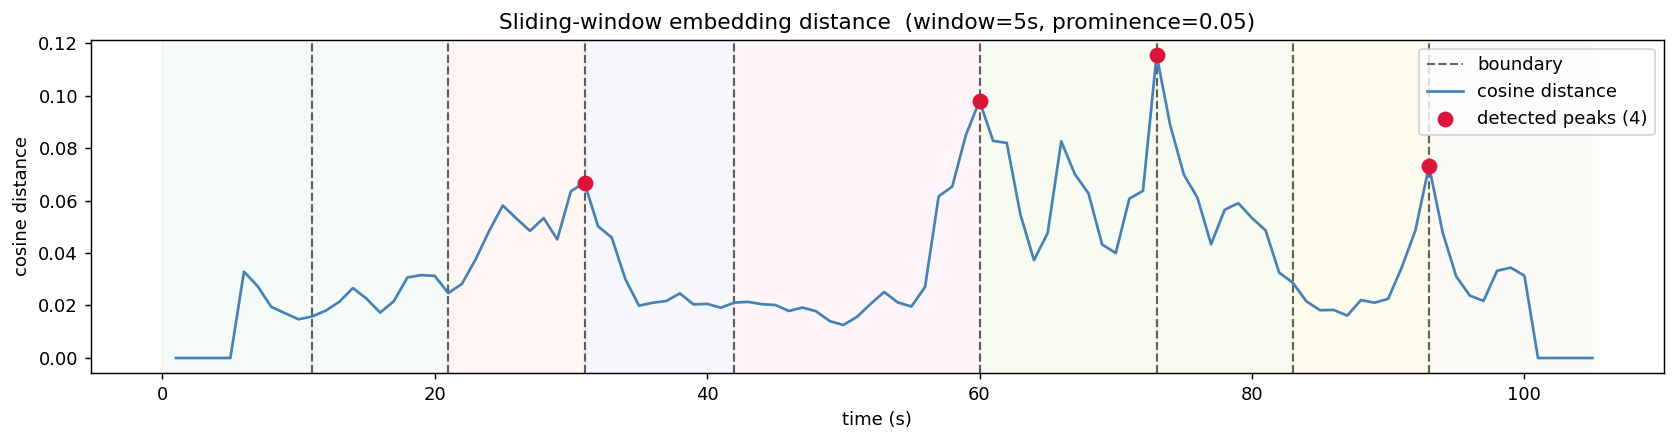

Peak timestamps: [31.0, 60.0, 73.0, 93.0]


In [77]:
WINDOW = 5   # ← match --window in the pipeline (default 10; lower for short clips)
PROMINENCE = 0.05

n = len(embeddings)
scores = np.zeros(n)
for t in range(WINDOW, n - WINDOW):
    left  = embeddings[t - WINDOW : t].mean(axis=0)
    right = embeddings[t : t + WINDOW].mean(axis=0)
    scores[t] = cosine_dist(left, right)

peaks, props = find_peaks(scores, prominence=PROMINENCE, distance=WINDOW)

fig, ax = plt.subplots(figsize=(13, 3.5))
add_scene_bands(ax)
ax.plot(emb_ts, scores, color="steelblue", lw=1.5, label="cosine distance")
ax.scatter(emb_ts[peaks], scores[peaks], color="crimson", zorder=5,
           s=60, label=f"detected peaks ({len(peaks)})")
ax.set_xlabel("time (s)")
ax.set_ylabel("cosine distance")
ax.set_title(f"Sliding-window embedding distance  (window={WINDOW}s, prominence={PROMINENCE})")
ax.legend()
plt.tight_layout()
plt.show()

print("Peak timestamps:", emb_ts[peaks].tolist())

---
## 2 · Ruptures — kernel change point detection

`ruptures` works fundamentally differently from the sliding window: instead of comparing local averages, it fits a **global** segmentation that minimises the total within-segment variance in a kernel-projected space (RBF kernel by default). It sees the full sequence at once and finds the *best* set of breakpoints for a given penalty cost.

### What ruptures sees: the pairwise cosine similarity matrix
The heatmap below is the N×N matrix of cosine similarities between every pair of embedding frames. Ruptures effectively looks for block structure in this matrix — a region where frames are highly similar to each other (bright block on the diagonal) and dissimilar to frames outside (dark off-diagonal).

- **Bright diagonal blocks** → frames that belong together visually — one scene.
- **Sharp transition between blocks** → a scene boundary.
- **Gradual fade** → slow visual transition, harder for both methods to pin down.

### Tuning `PENALTY`
The penalty controls how many breakpoints ruptures is allowed to place. It is a cost charged per breakpoint added; higher penalty → fewer scenes.

| Penalty | Effect |
|---------|--------|
| 0.1 – 0.5 | Many fine-grained segments — over-segmentation |
| 1 – 3 | Typical range for drone footage |
| 5 – 15 | Coarse segmentation — only major scene changes |
| > 20 | Usually produces a single segment |

Unlike `--prominence` in the sliding window, penalty has no intuitive unit — tune it by looking at the boundary comparison plot below.

PCA: 1152d → 50d  (95.8% variance retained)
Ruptures boundaries (penalty=1.2): [11.0, 21.0, 31.0, 42.0, 60.0, 73.0, 83.0, 93.0]


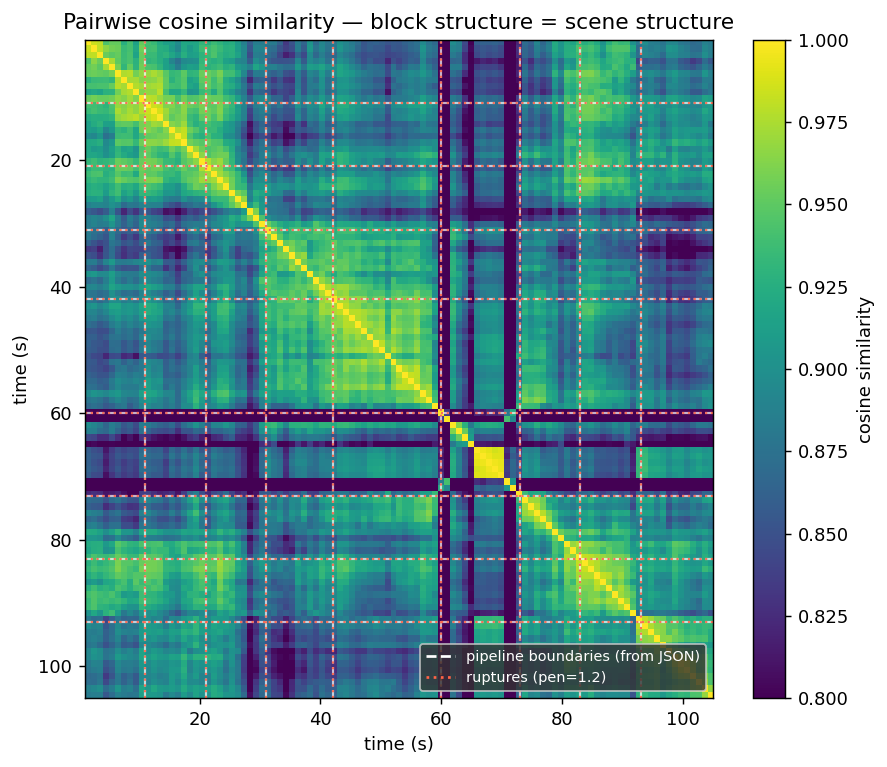

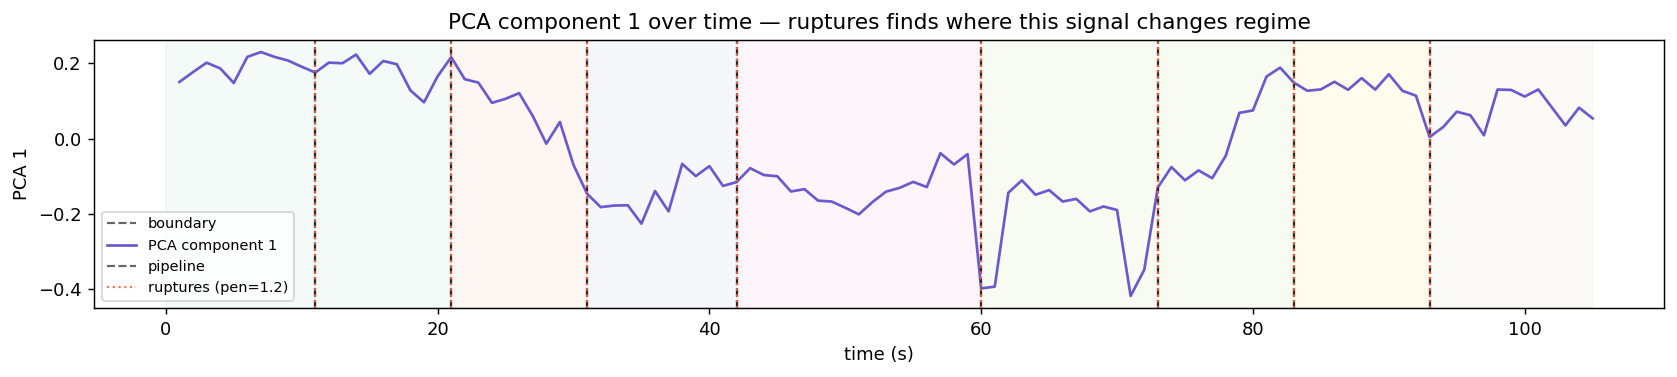

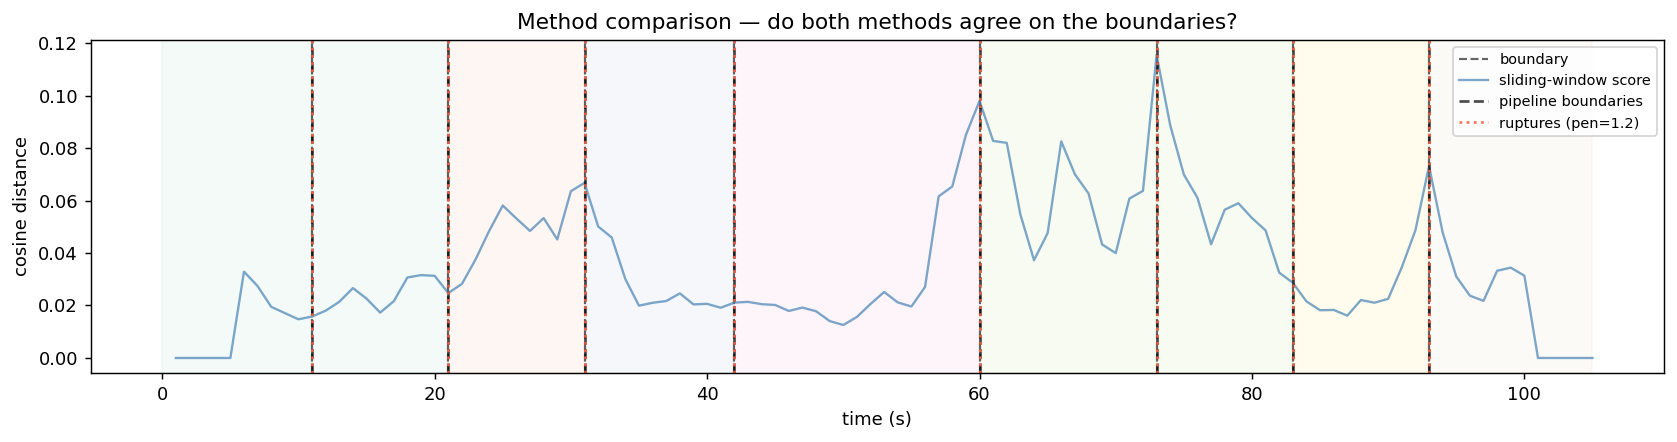

In [88]:
import ruptures as rpt
from sklearn.decomposition import PCA

PENALTY   = 1.2   # ← tune this; higher = fewer scenes
MIN_SIZE  = 10     # minimum segment length in frames

# ── PCA reduction (same as pipeline's ruptures path) ──────────────────────
pca = PCA(n_components=min(50, embeddings.shape[1], len(embeddings) - 1))
emb_reduced = pca.fit_transform(embeddings)
explained = pca.explained_variance_ratio_.sum()
print(f"PCA: {embeddings.shape[1]}d → {emb_reduced.shape[1]}d  ({explained:.1%} variance retained)")

# ── Run ruptures ───────────────────────────────────────────────────────────
algo = rpt.KernelCPD(kernel="rbf", min_size=MIN_SIZE).fit(emb_reduced)
bkps = algo.predict(pen=PENALTY)           # last entry = len(emb_reduced)
rpt_indices = [b for b in bkps if b < len(emb_ts)]
rpt_times   = emb_ts[rpt_indices].tolist() if rpt_indices else []
print(f"Ruptures boundaries (penalty={PENALTY}): {rpt_times}")

# ── Figure 1: pairwise cosine similarity heatmap ──────────────────────────
sim = embeddings @ embeddings.T            # (N, N) — L2-normalised → cosine sim

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim, aspect="auto", origin="upper",
               cmap="viridis", vmin=0.8, vmax=1.0,
               extent=[emb_ts[0], emb_ts[-1], emb_ts[-1], emb_ts[0]])
plt.colorbar(im, ax=ax, label="cosine similarity")

# Overlay boundaries from JSON (pipeline run)
for b in boundaries[1:-1]:
    ax.axhline(b, color="white",  lw=1.2, ls="--", alpha=0.7)
    ax.axvline(b, color="white",  lw=1.2, ls="--", alpha=0.7)

# Overlay ruptures boundaries (notebook run)
for b in rpt_times:
    ax.axhline(b, color="tomato", lw=1.2, ls=":",  alpha=0.9)
    ax.axvline(b, color="tomato", lw=1.2, ls=":",  alpha=0.9)

handles = [
    plt.Line2D([0], [0], color="white",  ls="--", lw=1.5, label="pipeline boundaries (from JSON)"),
    plt.Line2D([0], [0], color="tomato", ls=":",  lw=1.5, label=f"ruptures (pen={PENALTY})"),
]
ax.legend(handles=handles, loc="lower right", fontsize=8,
          facecolor="0.2", labelcolor="white")
ax.set_xlabel("time (s)")
ax.set_ylabel("time (s)")
ax.set_title("Pairwise cosine similarity — block structure = scene structure")
plt.tight_layout()
plt.show()

# ── Figure 2: PCA component 1 over time with both sets of boundaries ──────
pc1 = emb_reduced[:, 0]

fig, ax = plt.subplots(figsize=(13, 3))
add_scene_bands(ax)

ax.plot(emb_ts, pc1, color="slateblue", lw=1.5, label="PCA component 1")

for b in boundaries[1:-1]:
    ax.axvline(b, color="black", lw=1.2, ls="--", alpha=0.6,
               label="pipeline" if b == boundaries[1] else "")

for b in rpt_times:
    ax.axvline(b, color="tomato", lw=1.2, ls=":", alpha=0.9,
               label=f"ruptures (pen={PENALTY})" if b == rpt_times[0] else "")

ax.set_xlabel("time (s)")
ax.set_ylabel("PCA 1")
ax.set_title("PCA component 1 over time — ruptures finds where this signal changes regime")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Figure 3: side-by-side boundary comparison on the sliding-window signal
fig, ax = plt.subplots(figsize=(13, 3.5))
add_scene_bands(ax)
ax.plot(emb_ts, scores, color="steelblue", lw=1.3, alpha=0.7, label="sliding-window score")

for b in boundaries[1:-1]:
    ax.axvline(b, color="black", lw=1.5, ls="--", alpha=0.7,
               label="pipeline boundaries" if b == boundaries[1] else "")

for b in rpt_times:
    ax.axvline(b, color="tomato", lw=1.5, ls=":", alpha=0.9,
               label=f"ruptures (pen={PENALTY})" if b == rpt_times[0] else "")

ax.set_xlabel("time (s)")
ax.set_ylabel("cosine distance")
ax.set_title("Method comparison — do both methods agree on the boundaries?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 2 · Frame-to-frame cosine distance (fine-grained)
Consecutive embedding similarity — useful to spot sudden cuts or gradual transitions.

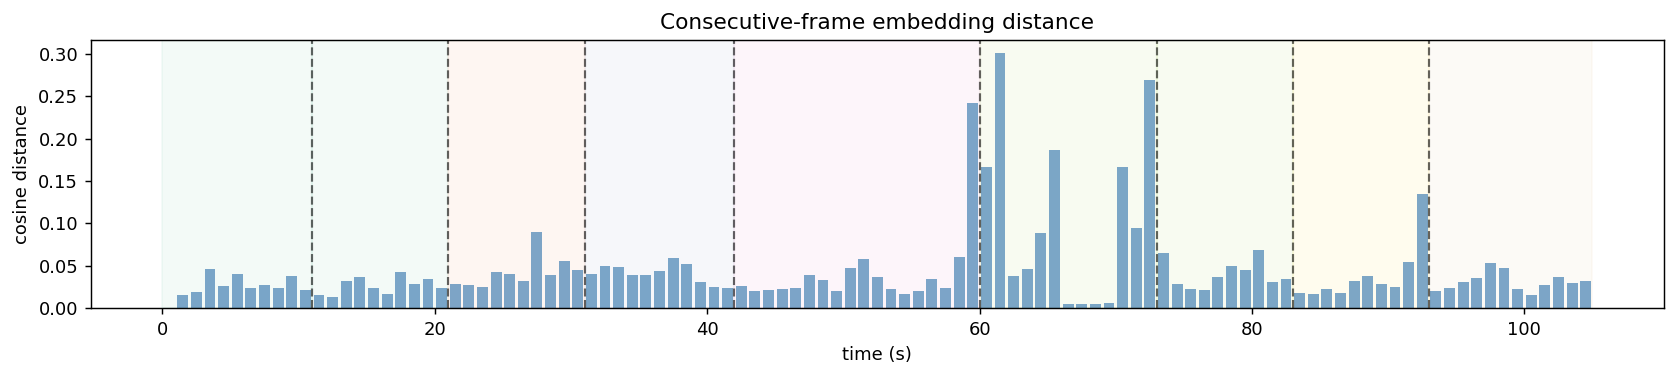

In [89]:
frame_dists = np.array([
    cosine_dist(embeddings[i], embeddings[i+1])
    for i in range(len(embeddings) - 1)
])
mid_ts = (emb_ts[:-1] + emb_ts[1:]) / 2

fig, ax = plt.subplots(figsize=(13, 3))
add_scene_bands(ax)
ax.bar(mid_ts, frame_dists, width=0.8, color="steelblue", alpha=0.7)
ax.set_xlabel("time (s)")
ax.set_ylabel("cosine distance")
ax.set_title("Consecutive-frame embedding distance")
plt.tight_layout()
plt.show()

---
## 3 · Embedding landscape — UMAP 2-D projection
Each dot = one second of video. Color = time. Clusters = visually similar segments.

/Users/nploch/Documents/Code/ai-video-cutter/.edit/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


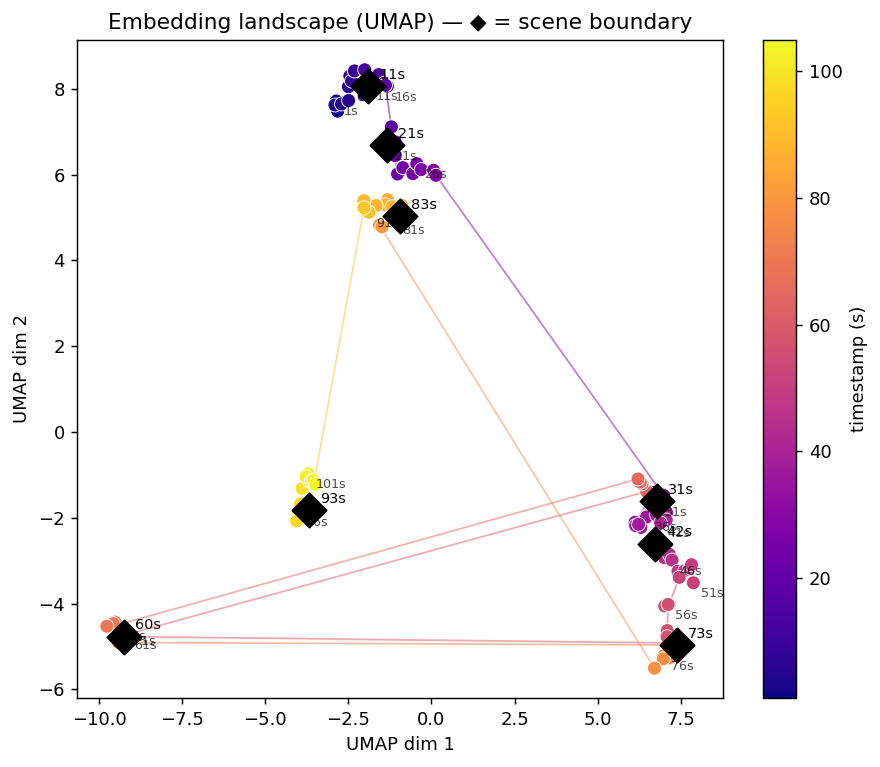

Projection method: UMAP  (install `umap-learn` for UMAP)


In [90]:
try:
    from umap import UMAP
    reducer = UMAP(n_components=2, n_neighbors=min(10, len(embeddings)-1), random_state=42)
    proj = reducer.fit_transform(embeddings)
    method = "UMAP"
except ImportError:
    from sklearn.decomposition import PCA
    proj = PCA(n_components=2).fit_transform(embeddings)
    method = "PCA"

fig, ax = plt.subplots(figsize=(7, 6))
norm = Normalize(vmin=emb_ts.min(), vmax=emb_ts.max())
cmap = cm.plasma

# Draw trajectory
for i in range(len(proj) - 1):
    ax.plot(proj[i:i+2, 0], proj[i:i+2, 1],
            color=cmap(norm(emb_ts[i])), lw=1, alpha=0.5)

sc = ax.scatter(proj[:, 0], proj[:, 1],
                c=emb_ts, cmap="plasma", s=60, zorder=3, edgecolors="white", lw=0.5)

# Mark scene boundaries
for b in boundaries[1:-1]:
    idx = np.argmin(np.abs(emb_ts - b))
    ax.scatter(*proj[idx], s=180, marker="D", color="black", zorder=5)
    ax.annotate(f"{b:.0f}s", proj[idx], textcoords="offset points",
                xytext=(6, 4), fontsize=8)

# Annotate every 5th frame with its timestamp
for i, (x, y) in enumerate(proj):
    if i % 5 == 0:
        ax.annotate(f"{emb_ts[i]:.0f}s", (x, y),
                    textcoords="offset points", xytext=(4, -8), fontsize=7, alpha=0.7)

plt.colorbar(sc, ax=ax, label="timestamp (s)")
ax.set_title(f"Embedding landscape ({method}) — ◆ = scene boundary")
ax.set_xlabel(f"{method} dim 1")
ax.set_ylabel(f"{method} dim 2")
plt.tight_layout()
plt.show()
print(f"Projection method: {method}  (install `umap-learn` for UMAP)")

---
## 4 · Per-frame quality metrics

Each metric is sampled once per second (at `--emb-fps`). Scene bands and keyframe markers (green dotted lines) are overlaid for reference.

---

### Sharpness — Laplacian variance
**What it measures:** The variance of the second spatial derivative of the grayscale image. Sharp edges produce large values; blurry images collapse toward zero.

**What to optimize for:** **High and stable.**

| Range | Interpretation |
|-------|---------------|
| > 5 000 | Crisp, excellent — ideal for a hero shot |
| 2 000 – 5 000 | Good, usable |
| 500 – 2 000 | Soft — acceptable for B-roll, not for a highlight cut |
| < 500 | Blurry — motion blur, out-of-focus, or compression artifact |

**Patterns to watch:**
- **Sudden drop within a scene** → wind jolt, fast pan, or subject crossing frame at speed.
- **Gradual decline from scene start to end** → drone is accelerating or decelerating; the sharpest frame is at the moment of lowest speed.
- **Consistently high across all scenes** → well-exposed, slow-moving footage — the pipeline's quality score will be high.
- **Dip at a scene boundary** → the boundary was correctly placed; the blur is the transition moment.

---

### Mean brightness — grayscale average (0 – 255)
**What it measures:** The average luminance across the full frame.

**What to optimize for:** **Stable, and centered around 100 – 140** (slightly underexposed is preferred for drone/sky footage; it protects highlights).

| Range | Interpretation |
|-------|---------------|
| 100 – 140 | Well-exposed, typical drone sky/landscape |
| 140 – 180 | Bright — acceptable if highlights are not clipping |
| > 200 | Overexposed — likely flying into the sun or at noon |
| 50 – 100 | Underexposed — dawn, dusk, or heavy cloud |
| < 50 | Very dark — near-night, heavy shadow |

**Patterns to watch:**
- **Slow drift upward** → drone turning toward the sun or flying from shadow into open sky.
- **Sudden jump** → scene cut, or drone emerging from a shadow/tunnel.
- **High brightness + high highlight clipping** → overexposed scene, discard or de-expose in post.
- **Stable line near 120** → ideal — the automatic exposure is locked in.

---

### Highlight clipping % — pixels > 250
**What it measures:** Percentage of pixels that are blown out to near-white. These pixels contain zero recoverable detail.

**What to optimize for:** **As close to 0 % as possible. Hard limit: < 1 %.**

| Range | Interpretation |
|-------|---------------|
| 0 – 0.5 % | Excellent — no meaningful clipping |
| 0.5 – 2 % | Acceptable — small specular reflections or sun at edge |
| 2 – 5 % | Caution — sky/cloud overexposure, visible in grading |
| > 5 % | Reject — significant blown-out areas, unrecoverable |

**Patterns to watch:**
- **Spike at one frame** → drone briefly pointed directly at the sun; isolated, often recoverable with a cut.
- **Sustained plateau** → the entire scene is overexposed; lower exposure or discard.
- **Rising trend** → drone flying into brighter area; the scene boundary should be here.

---

### Shadow clipping % — pixels < 5
**What it measures:** Percentage of pixels crushed to near-black. Detail in these areas is lost.

**What to optimize for:** **Low, but some is normal in high-contrast outdoor footage. Soft limit: < 3 %.**

| Range | Interpretation |
|-------|---------------|
| 0 – 1 % | Very clean — flat lighting or overcast sky |
| 1 – 3 % | Normal — natural shadows from trees, buildings |
| 3 – 8 % | High contrast — sunrise/sunset, deep urban canyons |
| > 8 % | Underexposed — raise exposure or discard |

**Patterns to watch:**
- **Shadow clipping rising as highlight clipping falls (or vice versa)** → the drone is rebalancing its exposure mid-scene — a good place to cut.
- **Both clipping values near zero simultaneously** → flat, soft lighting — footage will grade easily.
- **High shadow clipping + low magnitude flow** → hovering over a dark subject; consider whether the scene is intentionally moody or just underexposed.

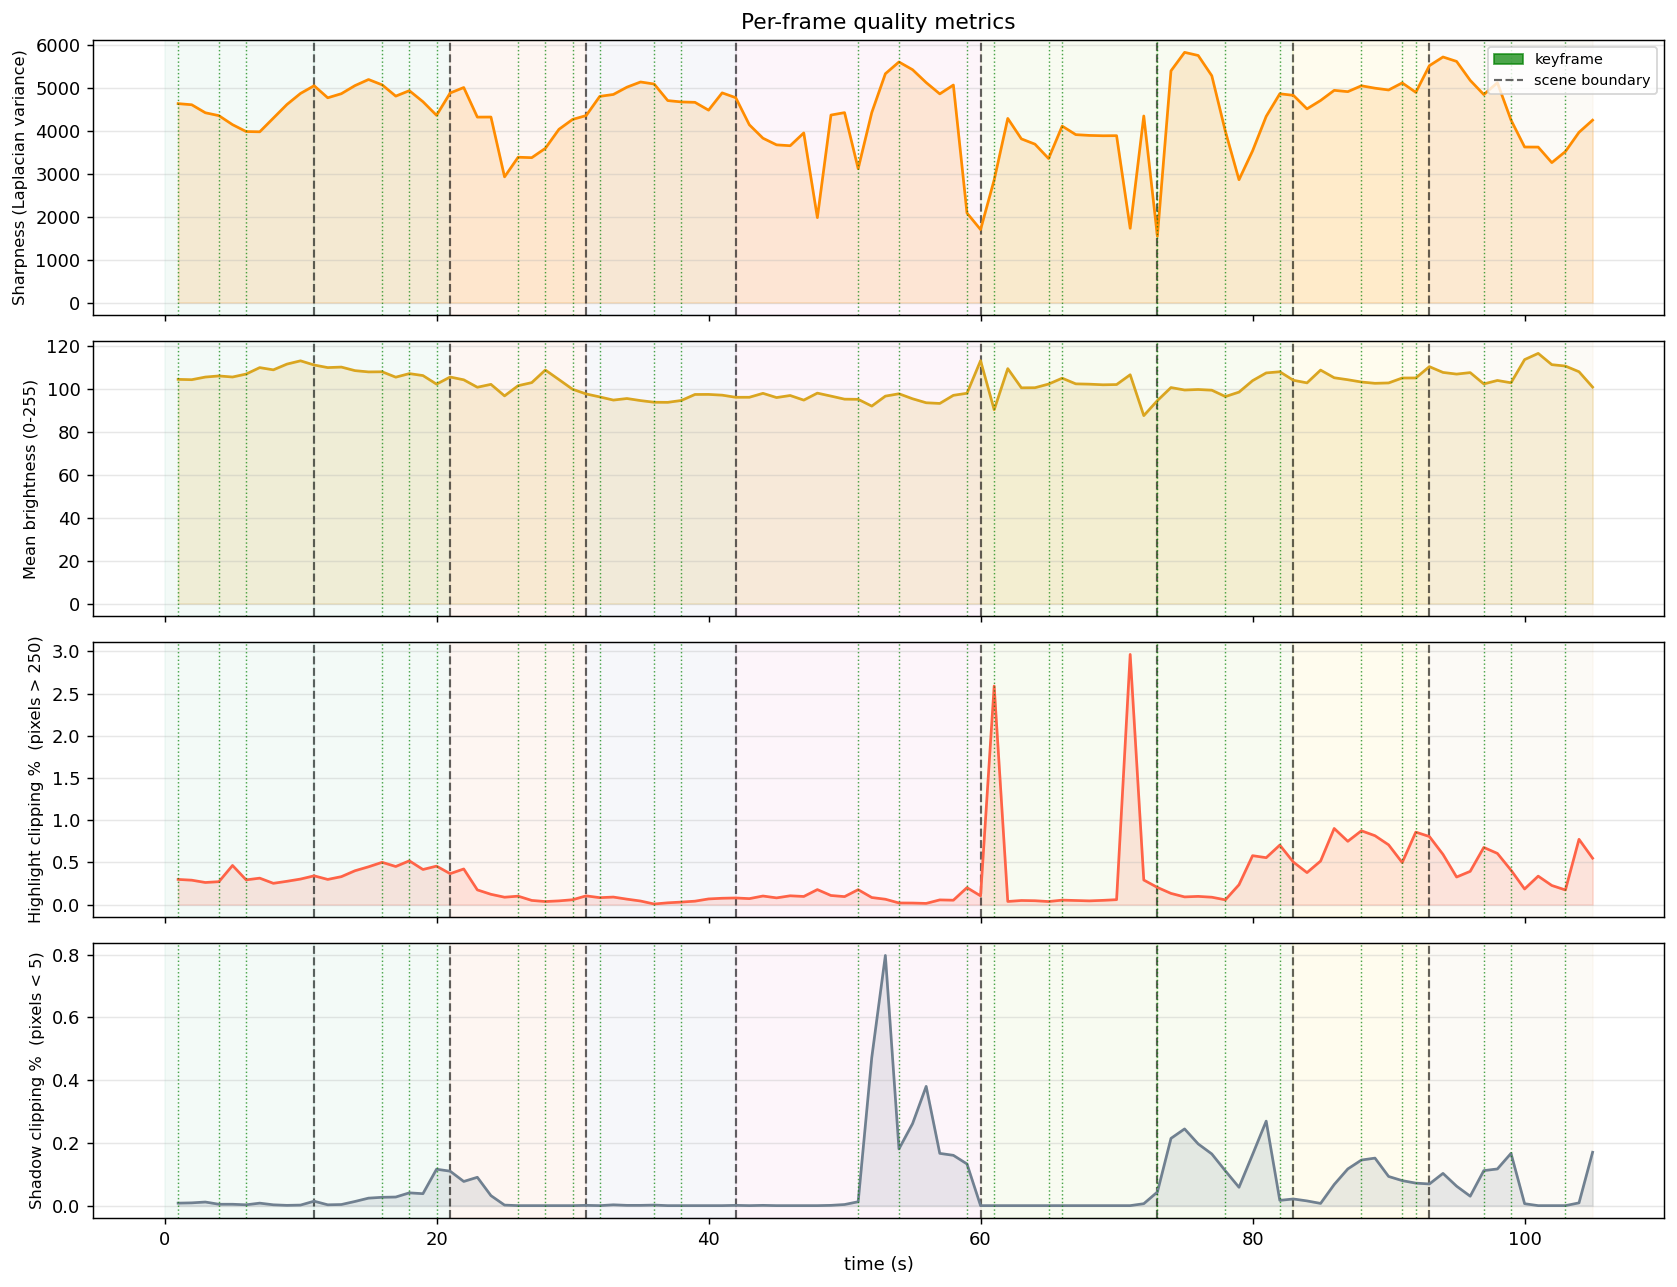

In [91]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
metrics = [
    ("sharpness",          "Sharpness (Laplacian variance)",    "darkorange"),
    ("mean_brightness",    "Mean brightness (0-255)",            "goldenrod"),
    ("highlight_clip_pct", "Highlight clipping %  (pixels > 250)", "tomato"),
    ("shadow_clip_pct",    "Shadow clipping %  (pixels < 5)",   "slategrey"),
]

for ax, (col, title, color) in zip(axes, metrics):
    add_scene_bands(ax)
    ax.plot(fm["timestamp"], fm[col], color=color, lw=1.5)
    ax.fill_between(fm["timestamp"], fm[col], alpha=0.15, color=color)

    # Mark keyframes
    for s in scenes_sorted:
        for kf in s["keyframe_timestamps"]:
            ax.axvline(kf, color="green", lw=0.8, ls=":", alpha=0.7)

    ax.set_ylabel(title, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("time (s)")
# Legend
handles = [
    mpatches.Patch(color="green", alpha=0.7, label="keyframe"),
    plt.Line2D([0], [0], color="black", ls="--", lw=1.2, alpha=0.6, label="scene boundary"),
]
axes[0].legend(handles=handles, loc="upper right", fontsize=8)
axes[0].set_title("Per-frame quality metrics")
plt.tight_layout()
plt.show()

---
## 5 · Optical flow — magnitude & coherence over time

Flow is computed between consecutive frames at `--flow-fps` (default 4 fps) using the Farnebäck dense optical flow algorithm. Every pixel gets a motion vector; the two statistics below summarise the whole field.

---

### Flow magnitude — mean pixel displacement per frame
**What it measures:** Average number of pixels each point in the frame moved between two consecutive frames (at the flow resolution, default 640 px wide). Captures the combined effect of camera motion and subject motion.

**What to optimize for:** **Moderate and consistent within a scene.** Neither extreme is ideal.

| Range (px) | Drone interpretation |
|------------|---------------------|
| 0 – 2 | Hovering, locked off — great for establishing/detail shots |
| 2 – 10 | Slow, deliberate move — cinematic pan, gentle ascent |
| 10 – 25 | Active flight — tracking, reveal, fly-through |
| 25 – 60 | Fast manoeuvre — banking turn, rapid descent |
| > 60 | Extreme speed or jolt — usually unusable unless intentional |

**Patterns to watch:**
- **Flat, low line (< 3 px)** → drone is hovering; combined with high sharpness and high coherence = excellent scene for a hero shot.
- **Smooth bell curve** → drone accelerated, held speed, then decelerated — a complete cinematic move within the scene.
- **Sharp spike followed by return to baseline** → wind gust, sudden yaw correction, or object entering frame; the spike frame is likely blurry (check sharpness).
- **Sustained high magnitude for the whole scene** → fast tracking or flyover; dynamic but may be too motion-blurred for static selects.
- **Magnitude near zero at scene boundaries** → the pipeline correctly placed a boundary when the drone paused between moves.

---

### Flow coherence — uniformity of the motion field (0 – 1)
**What it measures:** The length of the mean unit direction vector across all pixels. If all pixels point the same way, coherence = 1. If they point in random directions, coherence ≈ 0.

Technically: `coherence = |mean(cos θ_i), mean(sin θ_i)|` — it is the resultant vector length of the circular mean.

**What to optimize for:** **High (> 0.7) for cinematic, intentional-looking footage.**

| Range | Interpretation |
|-------|---------------|
| 0.85 – 1.0 | Pure translation — clean pan, dolly, or ascent; whole frame moves as one |
| 0.65 – 0.85 | Mostly uniform — slight parallax or subject motion on top of camera move |
| 0.40 – 0.65 | Mixed — camera rotation, complex scene, or partial obstruction |
| 0.20 – 0.40 | Chaotic — turbulence, rapid rotation, or scene with many independent movers |
| < 0.20 | Incoherent — drone spinning, severe shake, or nearly static scene with noise |

**Reading coherence and magnitude together:**

| Magnitude | Coherence | What it looks like |
|-----------|-----------|-------------------|
| Low | High | Hovering with almost no drift — locked, tripod-like |
| High | High | Clean, fast camera move — cinematic flythrough |
| Low | Low | Barely moving but direction is jittery — wind shake at hover |
| High | Low | Fast and chaotic — turbulence, rotation, or dynamic action scene |

**Patterns to watch:**
- **Coherence drops suddenly while magnitude stays constant** → the drone started rotating (yaw) mid-move; the scene will feel less clean.
- **Both magnitude and coherence drop at the same time** → drone slowed to a stop and is settling; natural scene endpoint.
- **Coherence oscillating rapidly** → propeller wash or wind buffeting; the footage may appear stable to the eye but will feel "nervous" on a large screen.
- **Coherence consistently > 0.9 for 5+ seconds** → one of the cleanest drone moves possible — prioritise this scene.

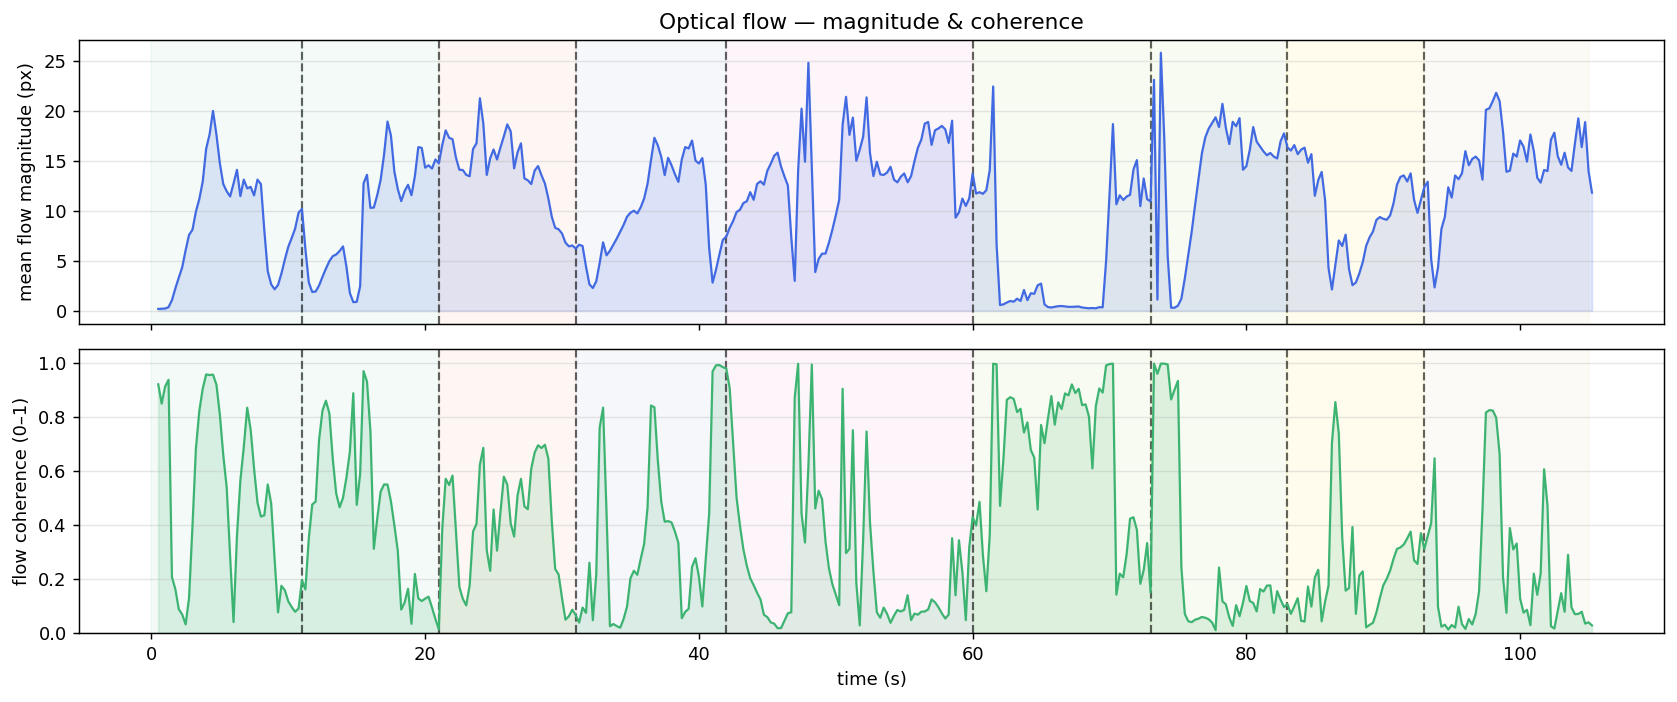

In [92]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)

add_scene_bands(ax1)
ax1.plot(flo["timestamp"], flo["mean_magnitude"], color="royalblue", lw=1.2)
ax1.fill_between(flo["timestamp"], flo["mean_magnitude"], alpha=0.15, color="royalblue")
ax1.set_ylabel("mean flow magnitude (px)")
ax1.grid(axis="y", alpha=0.3)

add_scene_bands(ax2)
ax2.plot(flo["timestamp"], flo["coherence"], color="mediumseagreen", lw=1.2)
ax2.fill_between(flo["timestamp"], flo["coherence"], alpha=0.15, color="mediumseagreen")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("flow coherence (0–1)")
ax2.set_xlabel("time (s)")
ax2.grid(axis="y", alpha=0.3)

ax1.set_title("Optical flow — magnitude & coherence")
plt.tight_layout()
plt.show()

---
## 6 · Dominant flow direction over time

**What it shows:** One arrow per second. The arrow points in the direction the majority of pixels were moving. Arrow length is proportional to mean magnitude (color also encodes magnitude via the plasma colormap: dark purple = slow, yellow = fast).

---

### How to read the angle

The angle is the standard mathematical convention, measured in radians from the positive X axis (right edge of the frame):

```
          ↑ N (up in frame, π/2)
          |
W (π) ←──┼──→ E (0 / right in frame)
          |
          ↓ S (down in frame, −π/2)
```

| Arrow direction | Drone / camera motion |
|----------------|----------------------|
| → East | Camera moving right (pan right) or drone flying right |
| ← West | Camera moving left (pan left) or drone flying left |
| ↑ North | Scene moving up in frame → drone **descending**, or subject approaching from below |
| ↓ South | Scene moving down in frame → drone **ascending**, or subject moving away |
| ↗ Northeast | Drone moving right and descending simultaneously |
| Rotating/spinning arrows | Drone yawing (rotating on its axis) |

> **Note:** Flow measures where the *pixels* move, which is opposite to where the *camera* moves. Pixels moving right means the camera is moving left (or the world is moving right past it). For a drone flying forward, near-ground pixels flow outward from the image centre.

---

### What to optimize for

**Consistent direction throughout a scene** is the sign of an intentional, purposeful camera move. Erratic direction changes within a single scene indicate:
- Yaw corrections (the operator fighting wind)
- Turbulence (involuntary pitch/roll)
- A scene boundary that the detector missed

**Patterns to watch:**
- **All arrows pointing the same way for 5+ seconds** → clean, linear camera move — high cinematic value.
- **Arrows rotating slowly through 360°** → drone is doing a slow orbit around a subject (if coherence stays high) or is being buffeted (if coherence is low).
- **Short arrows (low magnitude) with random directions** → hovering in wind; the drone is fighting to hold position. Despite looking static on screen, the stabiliser is working hard — check sharpness for micro-blur.
- **Arrow direction suddenly flips** → abrupt camera reversal or a hard cut that the scene detector should have caught; if no boundary is marked here, lower the `--prominence` threshold.
- **Long arrows (high magnitude) all pointing South** → drone is ascending quickly — the horizon is dropping through the frame.
- **Arrows pointing outward from centre (not visible here but inferable from direction changes)** → drone flying directly into or out of the scene (forward/backward dolly).

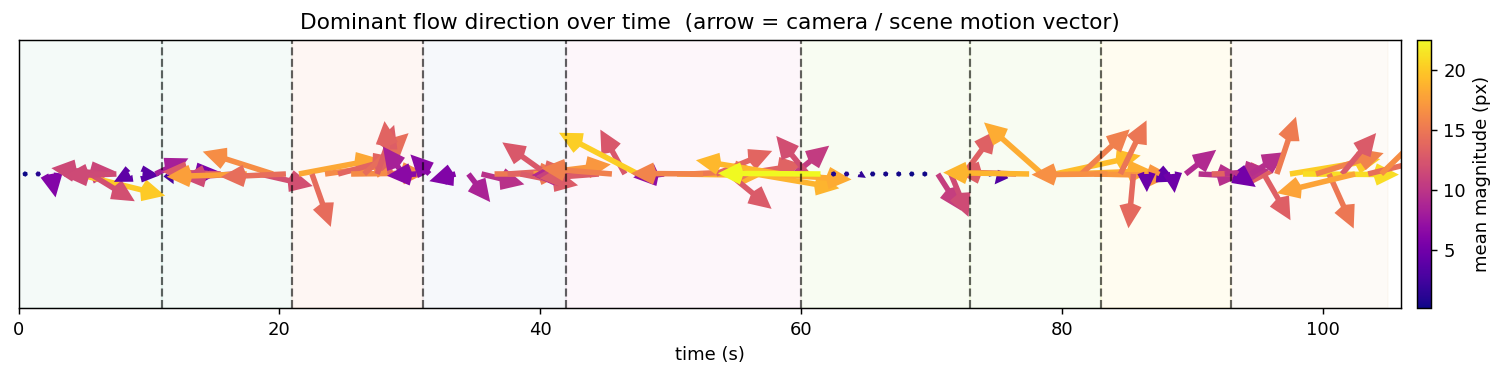

In [93]:
# Subsample to one arrow per second for readability
fps_flow = len(flo) / duration
step = max(1, int(round(fps_flow)))  # ~1 arrow per second
flo_sub = flo.iloc[::step].copy()

# Map angle + magnitude to dx/dy (scale magnitude for display)
scale = 0.35
flo_sub["dx"] = np.cos(flo_sub["dominant_direction"]) * flo_sub["mean_magnitude"] * scale
flo_sub["dy"] = np.sin(flo_sub["dominant_direction"]) * flo_sub["mean_magnitude"] * scale

fig, ax = plt.subplots(figsize=(13, 3))
add_scene_bands(ax, alpha=0.07)

norm_mag = Normalize(vmin=flo_sub["mean_magnitude"].min(),
                     vmax=flo_sub["mean_magnitude"].max())
colors = cm.plasma(norm_mag(flo_sub["mean_magnitude"].values))

ax.quiver(
    flo_sub["timestamp"], np.zeros(len(flo_sub)),
    flo_sub["dx"],        flo_sub["dy"],
    color=colors, scale=1, scale_units="xy", angles="xy",
    width=0.004, headwidth=4, headlength=4,
)
sm = cm.ScalarMappable(cmap="plasma", norm=norm_mag)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="mean magnitude (px)", pad=0.01)

ax.set_xlim(0, duration + 1)
ax.set_ylim(-12, 12)
ax.set_xlabel("time (s)")
ax.set_yticks([])
ax.set_title("Dominant flow direction over time  (arrow = camera / scene motion vector)")
plt.tight_layout()
plt.show()

---
## 7 · Flow direction polar histogram per scene
Shows the *distribution* of motion directions within each scene — useful to understand panning vs. hovering vs. descending.

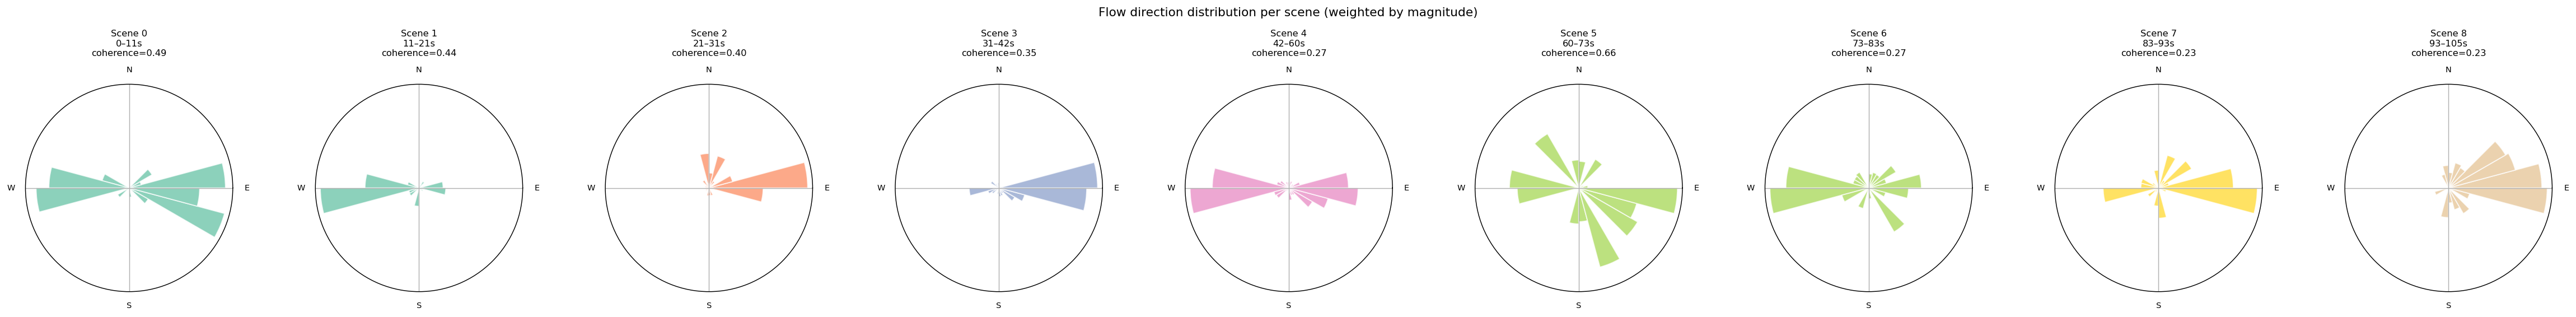

In [94]:
n_scenes = len(scenes_sorted)
fig, axes = plt.subplots(1, n_scenes, subplot_kw={"projection": "polar"},
                         figsize=(4 * n_scenes, 4))
if n_scenes == 1:
    axes = [axes]

bins = np.linspace(-np.pi, np.pi, 25)

for ax, s, color in zip(axes, scenes_sorted, SCENE_COLORS):
    mask = (flo["timestamp"] >= s["start_time"]) & (flo["timestamp"] < s["end_time"])
    angles = flo.loc[mask, "dominant_direction"].values
    mags   = flo.loc[mask, "mean_magnitude"].values

    counts, bin_edges = np.histogram(angles, bins=bins, weights=mags)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = bin_edges[1] - bin_edges[0]

    ax.bar(bin_centers, counts, width=width, color=color, alpha=0.75, edgecolor="white")
    ax.set_title(
        f"Scene {s['scene_id']}\n{s['start_time']:.0f}–{s['end_time']:.0f}s\n"
        f"coherence={s['avg_flow_coherence']:.2f}",
        fontsize=9, pad=10,
    )
    # Cardinal labels
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(["E", "N", "W", "S"], fontsize=8)
    ax.set_yticks([])

fig.suptitle("Flow direction distribution per scene (weighted by magnitude)", y=1.02)
plt.tight_layout()
plt.show()

---
## 8 · Scene summary table

In [95]:
rows = []
for s in scenes_sorted:
    rows.append({
        "scene_id":       s["scene_id"],
        "start (s)":      s["start_time"],
        "end (s)":        s["end_time"],
        "duration (s)":   s["duration"],
        "quality_score":  s["quality_score"],
        "avg_sharpness":  s["avg_sharpness"],
        "avg_brightness": round(s["avg_brightness"], 1),
        "flow_magnitude": s["avg_flow_magnitude"],
        "flow_coherence": s["avg_flow_coherence"],
        "keyframes":      s["keyframe_timestamps"],
    })

summary = pd.DataFrame(rows).set_index("scene_id")

def color_quality(val):
    r, g = int(255 * (1 - val)), int(255 * val)
    return f"background-color: rgba({r},{g},80,0.35)"

summary.style \
    .map(color_quality, subset=["quality_score"]) \
    .format({
        "quality_score":  "{:.3f}",
        "avg_sharpness":  "{:.0f}",
        "flow_magnitude": "{:.2f}",
        "flow_coherence": "{:.3f}",
    })

,start (s),end (s),duration (s),quality_score,avg_sharpness,avg_brightness,flow_magnitude,flow_coherence,keyframes
scene_id,,,,,,,,,
0,0.000000,11.000000,11.000000,0.846,4393,107.800000,8.66,0.488,"[1.0, 4.0, 6.0]"
1,11.000000,21.000000,10.000000,0.833,4882,107.800000,9.35,0.442,"[16.0, 18.0, 20.0]"
2,21.000000,31.000000,10.000000,0.820,4014,102.800000,14.10,0.400,"[26.0, 28.0, 30.0]"
3,31.000000,42.000000,11.000000,0.799,4790,95.800000,10.04,0.347,"[32.0, 36.0, 38.0]"
4,42.000000,60.000000,18.000000,0.778,4215,96.000000,13.53,0.268,"[51.0, 54.0, 59.0]"
5,60.000000,73.000000,13.000000,0.870,3499,102.000000,5.48,0.662,"[61.0, 65.0, 66.0]"
6,73.000000,83.000000,10.000000,0.784,4342,100.900000,13.92,0.274,"[73.0, 78.0, 82.0]"
7,83.000000,93.000000,10.000000,0.773,4894,104.500000,10.13,0.230,"[88.0, 91.0, 92.0]"
8,93.000000,105.000000,12.000000,0.785,4522,108.600000,14.73,0.231,"[97.0, 99.0, 103.0]"


---
## 9 · All metrics on one timeline

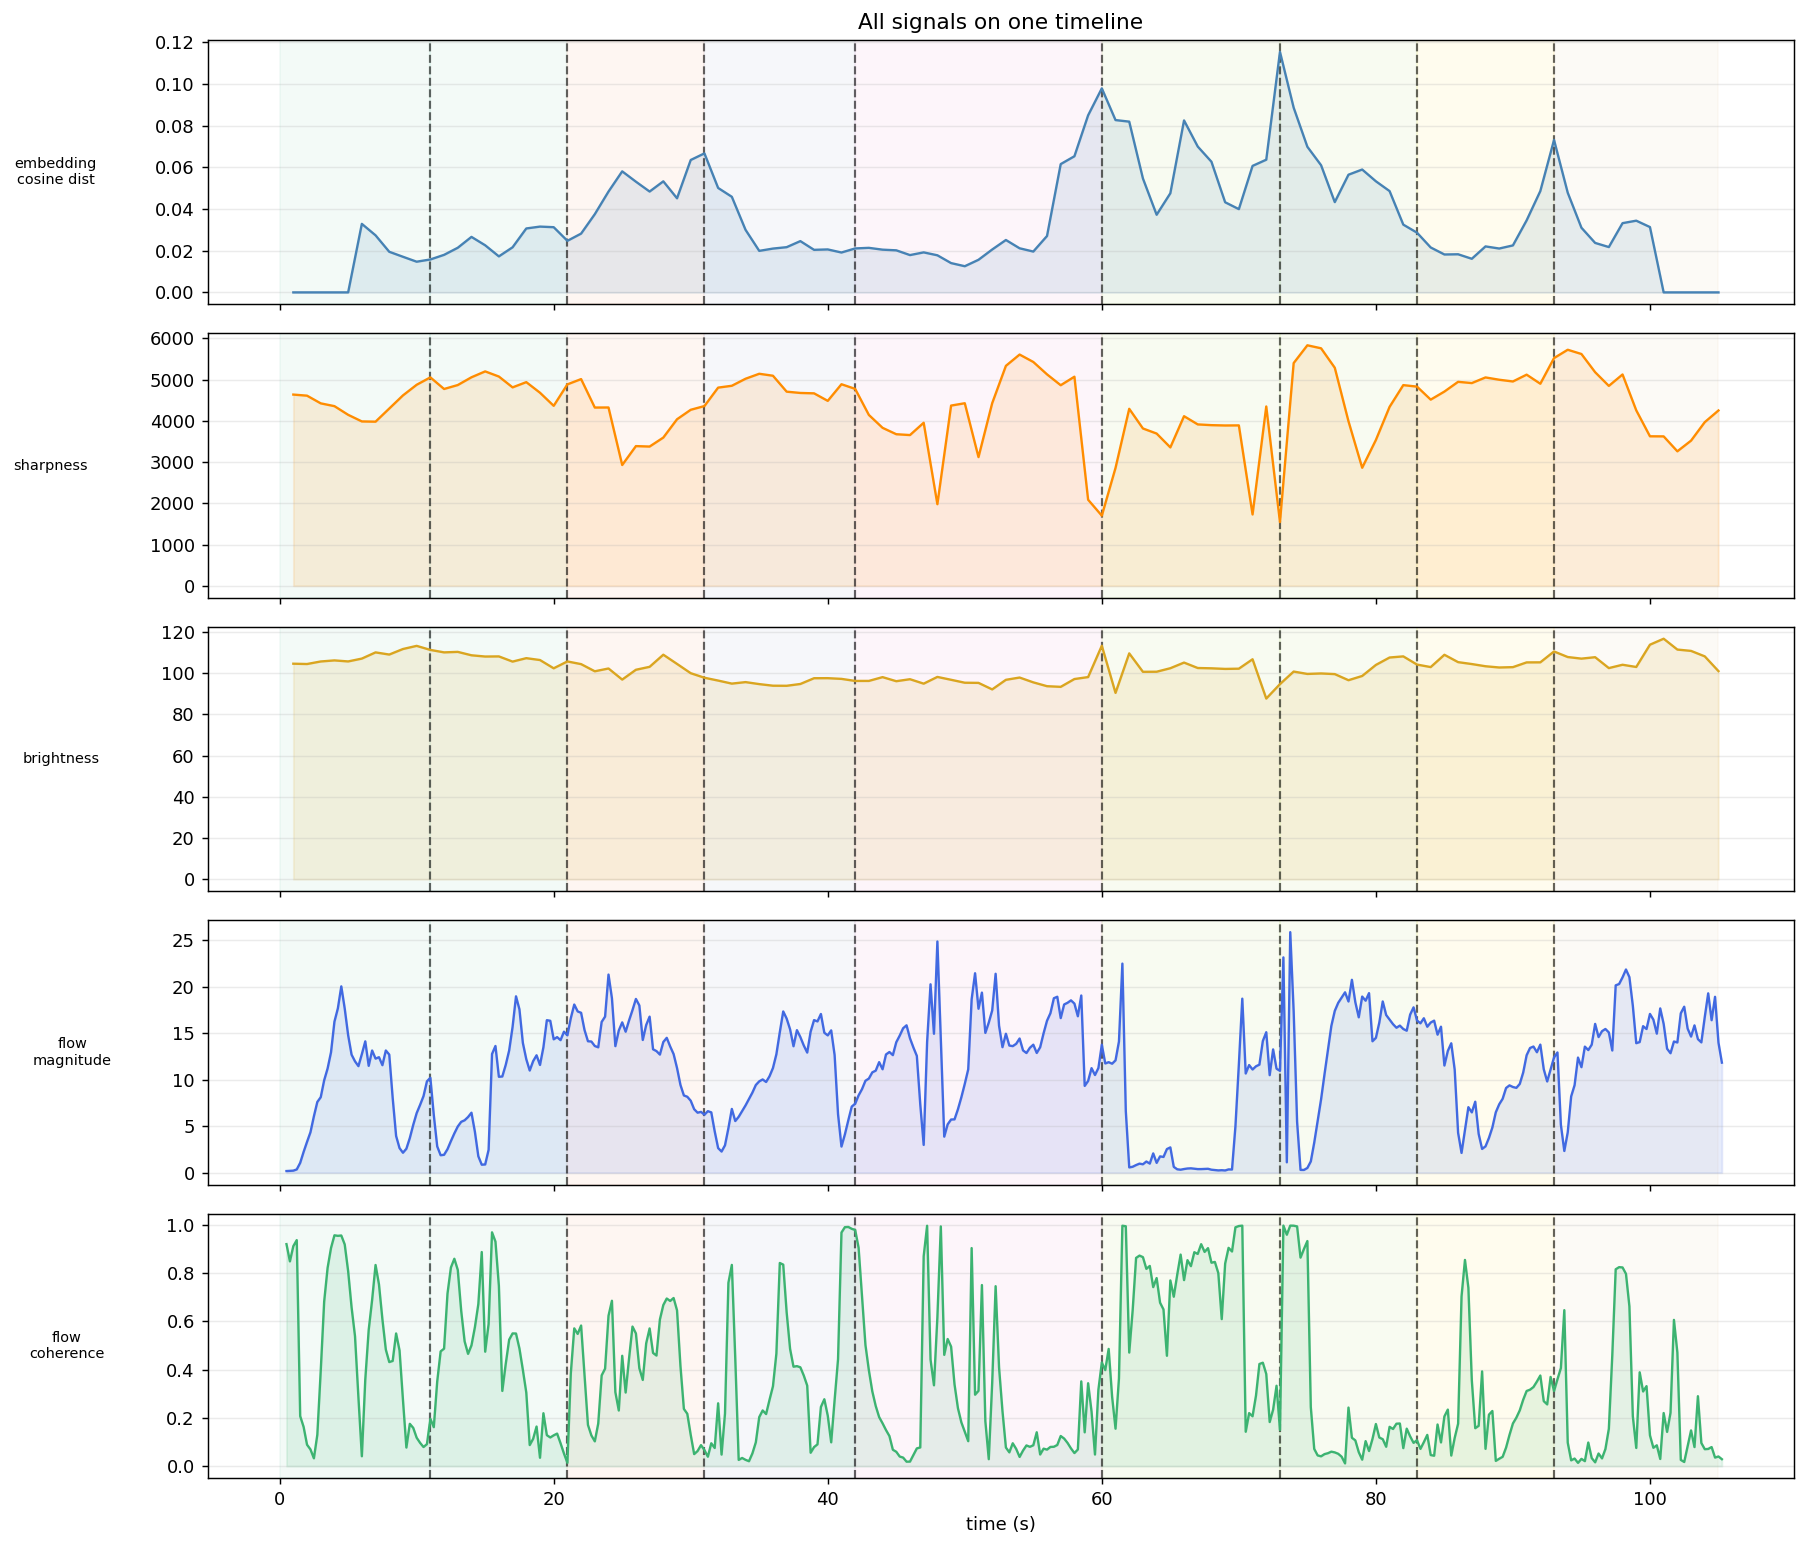

In [96]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

panels = [
    ("embedding\ncosine dist",  emb_ts,             scores,                    "steelblue"),
    ("sharpness",               fm["timestamp"],     fm["sharpness"],            "darkorange"),
    ("brightness",              fm["timestamp"],     fm["mean_brightness"],      "goldenrod"),
    ("flow\nmagnitude",         flo["timestamp"],    flo["mean_magnitude"],      "royalblue"),
    ("flow\ncoherence",         flo["timestamp"],    flo["coherence"],           "mediumseagreen"),
]

for ax, (label, xs, ys, color) in zip(axes, panels):
    add_scene_bands(ax)
    ax.plot(xs, ys, color=color, lw=1.3)
    ax.fill_between(xs, ys, alpha=0.12, color=color)
    ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=55, va="center")
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("time (s)")
axes[0].set_title("All signals on one timeline")
plt.tight_layout()
plt.show()